In [2]:
import sys
import os
import pandas as pd


sys.path.append(os.path.abspath(os.path.join('..')))
from src.data.connection import get_db_connection


conn = get_db_connection()

if conn:
    query_tables = "SELECT table_name FROM information_schema.tables WHERE table_schema = 'raw';"
    tables = pd.read_sql(query_tables, conn)['table_name'].tolist()
    
    all_data = {}

    for table in tables:
        all_data[table] = pd.read_sql(f"SELECT * FROM raw.{table}", conn)
        print(f"Таблица '{table}' загружена! (строк: {len(all_data[table])})")
    
    conn.close()
else:
    print("Ошибка подключения к СУБД")



Успешно: Подключение к СУБД установлено.
Таблица 'gender_submission' загружена! (строк: 418)
Таблица 'test' загружена! (строк: 418)
Таблица 'train' загружена! (строк: 891)


C:\Users\NoutSpace\AppData\Local\Temp\ipykernel_12724\3585626067.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  tables = pd.read_sql(query_tables, conn)['table_name'].tolist()
C:\Users\NoutSpace\AppData\Local\Temp\ipykernel_12724\3585626067.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  all_data[table] = pd.read_sql(f"SELECT * FROM raw.{table}", conn)


Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

Text(0.5, 0, 'Gender')

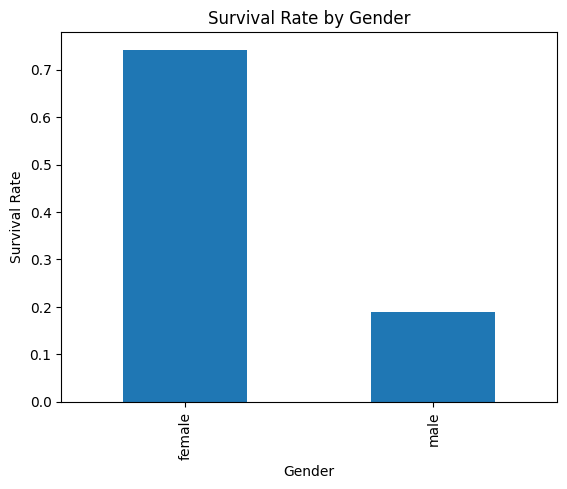

In [5]:
survival_rate_by_gender = train.groupby('Sex')['Survived'].mean()
ax = survival_rate_by_gender.plot(kind='bar', title='Survival Rate by Gender')
ax.set_ylabel('Survival Rate')
ax.set_xlabel('Gender')

Text(0.5, 0, 'Passenger Class')

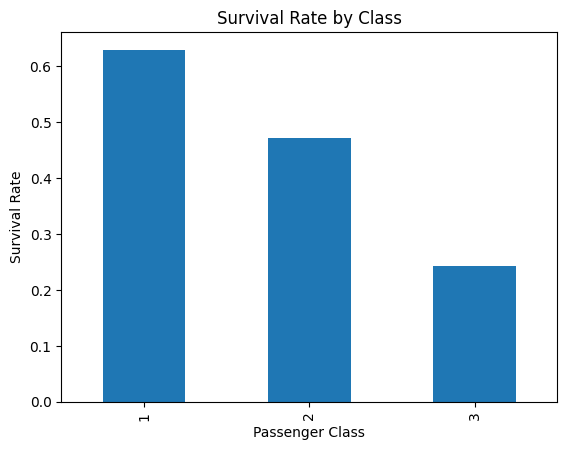

In [6]:
survival_rate_by_class = train.groupby('Pclass')['Survived'].mean()
ax = survival_rate_by_class.plot(kind='bar', title='Survival Rate by Class')
ax.set_ylabel('Survival Rate')
ax.set_xlabel('Passenger Class')

Text(0, 0.5, 'Survival Percentage (%)')

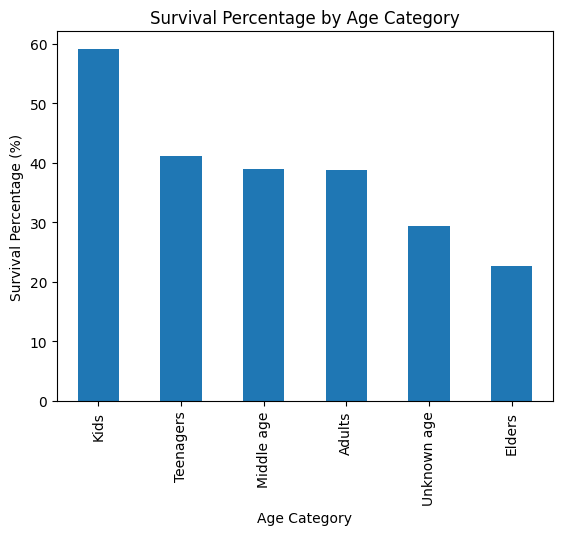

In [7]:
age_category = pd.cut(
	train["Age"],
	bins=[-1, 13, 18, 40, 60, float("inf")],
	labels=["Kids", "Teenagers", "Adults", "Middle age", "Elders"],
)
age_category = age_category.cat.add_categories(["Unknown age"]).fillna("Unknown age")

age_stats = (
	train.assign(Age_Category=age_category)
	.groupby("Age_Category", observed=True)
	.agg(
		total_passengers=("PassengerId", "size"),
		survival_percentage=("Survived", lambda x: x.mean() * 100),
	)
	.reset_index()
	.sort_values("survival_percentage", ascending=False)
)

ax = age_stats.plot.bar(
	x="Age_Category",
	y="survival_percentage",
	title="Survival Percentage by Age Category",
	legend=False,
)
ax.set_xlabel("Age Category")
ax.set_ylabel("Survival Percentage (%)")

         Family_Group  total_passengers  survival_percentage
1  With family member               354            50.564972
0               Alone               537            30.353818


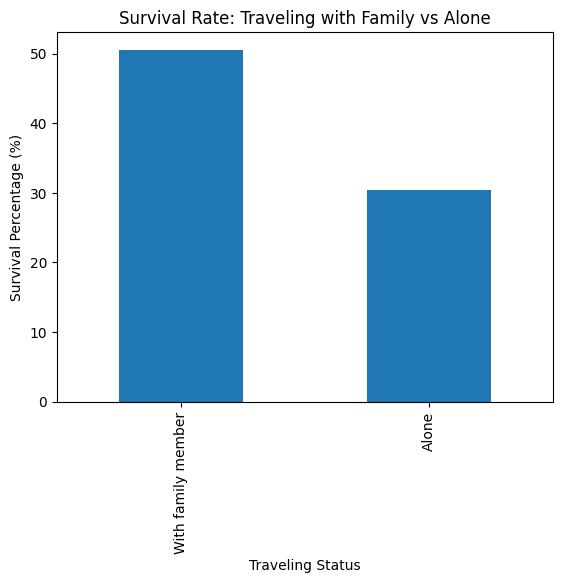

In [8]:
# Create a family group variable
train['Family_Group'] = train.apply(
	lambda row: 'With family member' if (row['Parch'] + row['SibSp']) > 0 else 'Alone',
	axis=1
)

# Calculate survival stats by family group
family_stats = (
	train.groupby('Family_Group')
	.agg(
		total_passengers=('PassengerId', 'size'),
		survival_percentage=('Survived', lambda x: x.mean() * 100)
	)
	.reset_index()
	.sort_values('survival_percentage', ascending=False)
)

# Plot the results
ax = family_stats.plot.bar(
	x='Family_Group',
	y='survival_percentage',
	title='Survival Rate: Traveling with Family vs Alone',
	legend=False
)
ax.set_xlabel('Traveling Status')
ax.set_ylabel('Survival Percentage (%)')
print(family_stats)

,Traveling_person_numb,total_passengers,survival_percentage
0,Other,844,39.691943
1,With 4 or more family member,47,14.893617


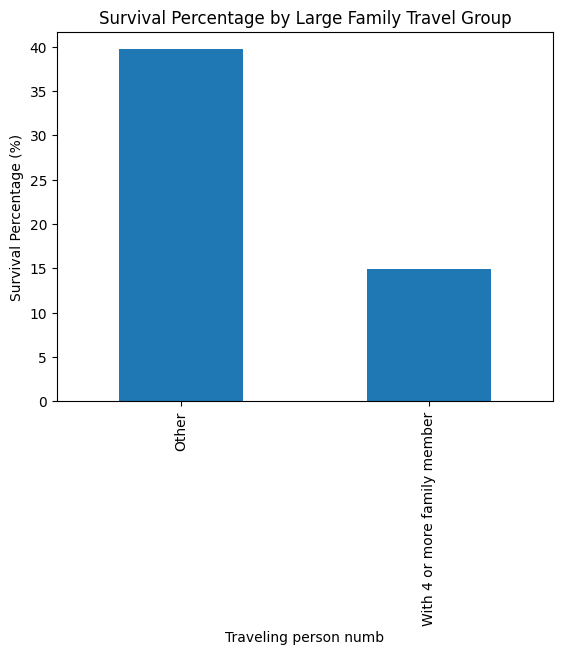

In [9]:
train['Traveling_person_numb'] = train.apply(
	lambda row: 'With 4 or more family member' if (row['Parch'] + row['SibSp']) > 4 else 'Other',
	axis=1
)

family_size_stats = (
	train.groupby('Traveling_person_numb')
	.agg(
		total_passengers=('PassengerId', 'size'),
		survival_percentage=('Survived', lambda x: x.mean() * 100)
	)
	.reset_index()
	.sort_values('survival_percentage', ascending=False)
)

ax = family_size_stats.plot.bar(
	x='Traveling_person_numb',
	y='survival_percentage',
	title='Survival Percentage by Large Family Travel Group',
	legend=False
)
ax.set_xlabel('Traveling person numb')
ax.set_ylabel('Survival Percentage (%)')
family_size_stats

,Embarked,total_passengers,survival_percentage
0,,2,100.000000
1,C,168,55.357143
2,Q,77,38.961039
3,S,644,33.695652


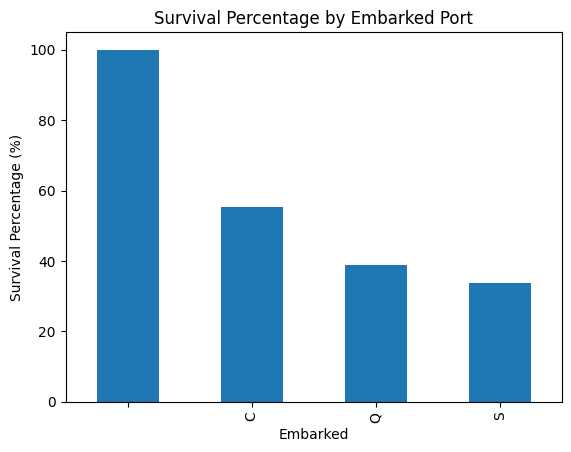

In [10]:
embarked_stats = (
	train.assign(Embarked=train["Embarked"].fillna("Unknown"))
	.groupby("Embarked", observed=True)
	.agg(
		total_passengers=("PassengerId", "size"),
		survival_percentage=("Survived", lambda x: x.mean() * 100),
	)
	.reset_index()
	.sort_values("survival_percentage", ascending=False)
)

ax = embarked_stats.plot.bar(
	x="Embarked",
	y="survival_percentage",
	title="Survival Percentage by Embarked Port",
	legend=False,
)
ax.set_xlabel("Embarked")
ax.set_ylabel("Survival Percentage (%)")
embarked_stats

,Age_Status,total_passengers,survival_percentage
1,with age,714,40.616246
0,Null age,177,29.378531


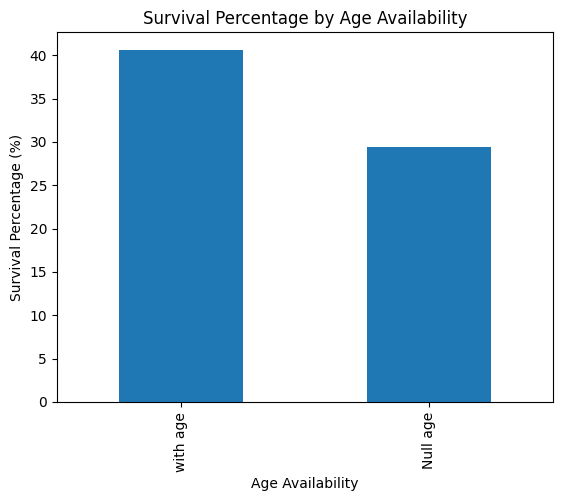

In [11]:
age_null_stats = (
	train.assign(
		Age_Status=train["Age"].notna().map({True: "with age", False: "Null age"})
	)
	.groupby("Age_Status", observed=True)
	.agg(
		total_passengers=("PassengerId", "size"),
		survival_percentage=("Survived", lambda x: x.mean() * 100),
	)
	.reset_index()
	.sort_values("survival_percentage", ascending=False)
)

ax = age_null_stats.plot.bar(
	x="Age_Status",
	y="survival_percentage",
	title="Survival Percentage by Age Availability",
	legend=False,
)
ax.set_xlabel("Age Availability")
ax.set_ylabel("Survival Percentage (%)")
age_null_stats

,fare_bracket,total_passengers,survival_rate_pct
0,Staff,15,6.67
1,Low cost,321,20.56
2,Medium cost,321,43.30
3,High cost,181,53.59
4,100+ Luxury,53,73.58


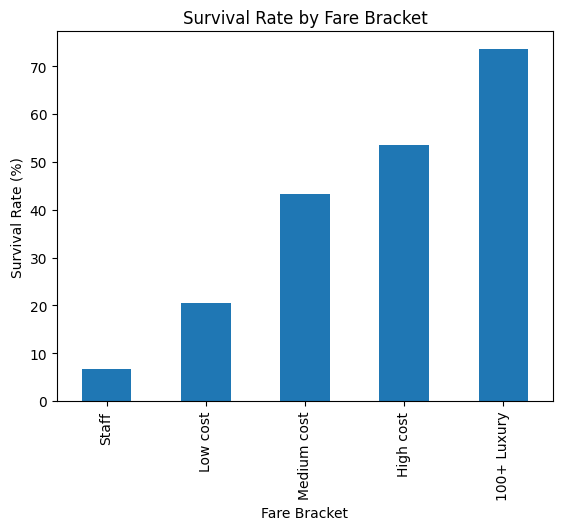

In [13]:
fare_bracket = pd.cut(
    train["Fare"],
    bins=[-0.01, 0, 10, 30, 100, train["Fare"].max()],
    labels=["Staff", "Low cost", "Medium cost", "High cost", "100+ Luxury"],
)

fare_bracket_stats = (
    train.assign(fare_bracket=fare_bracket)
    .groupby("fare_bracket", observed=True)
    .agg(
        total_passengers=("PassengerId", "size"),
        survival_rate_pct=("Survived", lambda x: round(x.mean() * 100, 2)),
    )
    .reset_index()
)

ax = fare_bracket_stats.plot.bar(
    x="fare_bracket",
    y="survival_rate_pct",
    title="Survival Rate by Fare Bracket",
    legend=False,
)
ax.set_xlabel("Fare Bracket")
ax.set_ylabel("Survival Rate (%)")
fare_bracket_stats